# Ground Truth (Human Annotation) Statistical Analysis

Statistical analysis of human annotations across demographic categories for:
- **Offensiveness** (`dataset/offensiveness/raw_data_llm.csv`)
- **Politeness** (`dataset/politeness_rating/raw_data_llm.csv`)

**N = 1000** (first 1000 rows of each dataset)

**Research Question:** Are there significant differences in human annotations between different demographic categories (gender, age, education)?

**Method:** Chi-squared tests of independence on contingency tables (demographic group × rating level)

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

OFF_PATH = '../../dataset/offensiveness/raw_data_llm.csv'
POL_PATH = '../../dataset/politeness_rating/raw_data_llm.csv'
N = 1000

off = pd.read_csv(OFF_PATH, nrows=N)
pol = pd.read_csv(POL_PATH, nrows=N)

DEMO_COLS = ['gender', 'age', 'education']

print(f'Offensiveness dataset: {off.shape[0]} rows')
print(f'Politeness dataset:    {pol.shape[0]} rows')

Offensiveness dataset: 1000 rows
Politeness dataset:    1000 rows


---
## Helper Functions

In [28]:
EDUCATION_ORDER = [
    'Less than a high school diploma',
    'High school diploma or equivalent',
    'College degree',
    'Graduate degree',
]

AGE_BIN_MAP = {
    '18-24': '18-29', '25-29': '18-29',
    '30-34': '30-39', '35-39': '30-39',
    '40-44': '40-49', '45-49': '40-49',
    '50-54': '50-59', '54-59': '50-59', '55-59': '50-59',
}
AGE_BIN_ORDER = ['18-29', '30-39', '40-49', '50-59', '>=60']


def descriptive_stats(series, label):
    desc = series.describe()
    print(f"\n{'='*55}")
    print(f"{label} — Descriptive Statistics (N={series.notna().sum()})")
    print(f"{'='*55}")
    print(f"  Mean   : {desc['mean']:.3f}")
    print(f"  Median : {series.median():.1f}")
    print(f"  Std    : {desc['std']:.3f}")
    print(f"  Min    : {desc['min']:.0f}  |  Max: {desc['max']:.0f}")
    vc = series.value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print("\n  Rating distribution:")
    for rating, count in vc.items():
        bar = chr(9608) * int(pct[rating] / 2)
        print(f"    {int(rating)}: {count:4d} ({pct[rating]:5.1f}%) {bar}")


def chi_squared_test(df, label_col, demo_col, alpha=0.05):
    sub = df[[demo_col, label_col]].dropna()
    ct = pd.crosstab(sub[demo_col], sub[label_col])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    pct_low = (expected < 5).sum() / expected.size * 100
    ratings = ct.columns.astype(float)
    group_means = ct.multiply(ratings).sum(axis=1) / ct.sum(axis=1)
    group_means = group_means.sort_values(ascending=False)
    return {
        'demographic': demo_col,
        'n': len(sub),
        'chi2': chi2,
        'dof': dof,
        'p_value': p,
        'significant': p < alpha,
        'pct_cells_low_expected': pct_low,
        'contingency_table': ct,
        'expected': expected,
        'group_means': group_means,
    }


def print_chi2_result(res, alpha=0.05):
    sig_str = f'  ** SIGNIFICANT (alpha={alpha}) **' if res['significant'] else '  (not significant)'
    print(f"\n  [{res['demographic']}]")
    print(f"    N = {res['n']}")
    print(f"    chi2({res['dof']}) = {res['chi2']:.3f},  p = {res['p_value']:.4f}{sig_str}")
    if res['pct_cells_low_expected'] > 20:
        print(f"    WARNING: {res['pct_cells_low_expected']:.0f}% of expected cells < 5 — interpret with caution")
    if res['significant']:
        gm = res['group_means']
        overall_mean = gm.mean()
        print(f"    Direction (mean rating per group, highest → lowest):")
        for grp, m in gm.items():
            direction = "above avg" if m > overall_mean else "below avg"
            print(f"      {grp}: {m}  [{direction}]")
        highest_grp, highest_val = gm.index[0], gm.iloc[0]
        lowest_grp,  lowest_val  = gm.index[-1], gm.iloc[-1]
        print(f"    → '{highest_grp}' rates highest ({highest_val}); '{lowest_grp}' rates lowest ({lowest_val})")


def run_all_tests(df, label_col, task_name, demo_cols=DEMO_COLS, alpha=0.05):
    results = []
    print(f"\n{'#'*60}")
    print(f"  Chi-Squared Tests: {task_name} ~ Demographic Group")
    print(f"  H0: rating distribution is independent of demographic group")
    print(f"  alpha = {alpha}")
    print(f"{'#'*60}")
    for col in demo_cols:
        res = chi_squared_test(df, label_col, col, alpha)
        results.append(res)
        print_chi2_result(res, alpha)
    return results


def get_common_groups(df1, df2, demo_col):
    """Return groups that appear in both datasets for a given demographic column."""
    groups1 = set(df1[demo_col].dropna().unique())
    groups2 = set(df2[demo_col].dropna().unique())
    return groups1 & groups2


def plot_rating_by_demo(df, label_col, demo_col, task_name, ax, common_groups=None):
    sub = df[[demo_col, label_col]].dropna().copy()

    # Bin age into broader brackets
    if demo_col == 'age':
        sub[demo_col] = sub[demo_col].map(lambda x: AGE_BIN_MAP.get(x, '>=60'))
        # common_groups not needed for age — always use fixed bin order
        present = [b for b in AGE_BIN_ORDER if b in sub[demo_col].unique()]
        ct = pd.crosstab(sub[demo_col], sub[label_col], normalize='index') * 100
        ct = ct.loc[present]
    else:
        # Restrict to groups shared across both tasks
        if common_groups is not None:
            sub = sub[sub[demo_col].isin(common_groups)]
        ct = pd.crosstab(sub[demo_col], sub[label_col], normalize='index') * 100

        # Sort education by level
        if demo_col == 'education':
            order = [e for e in EDUCATION_ORDER if e in ct.index]
            remaining = [g for g in ct.index if g not in order]
            ct = ct.loc[order + remaining]

    # Compute per-group % of all annotations in this task's subset
    total_counts = sub[demo_col].value_counts()
    total = total_counts.sum()

    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r', width=0.7)

    # X-axis tick labels with annotation %
    new_labels = [
        f'{group}\n({total_counts.get(group, 0) / total * 100:.0f}%)'
        for group in ct.index
    ]
    ax.set_xticklabels(new_labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{task_name}: {label_col} by {demo_col}', fontsize=10)
    ax.set_xlabel(demo_col, fontsize=9)
    ax.set_ylabel('% of annotations', fontsize=9)
    ax.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)


def summary_table(results, label):
    rows = []
    for r in results:
        rows.append({
            'Task': label,
            'Demographic': r['demographic'],
            'N': r['n'],
            'chi2': round(r['chi2'], 3),
            'df': r['dof'],
            'p-value': round(r['p_value'], 4),
            'Significant (alpha=0.05)': 'Yes' if r['significant'] else 'No',
            '% cells expected<5': round(r['pct_cells_low_expected'], 1),
        })
    return pd.DataFrame(rows)

---
## 1. Offensiveness

In [29]:
descriptive_stats(off['offensiveness'], 'Offensiveness')


Offensiveness — Descriptive Statistics (N=1000)
  Mean   : 1.638
  Median : 1.0
  Std    : 1.038
  Min    : 1  |  Max: 5

  Rating distribution:
    1:  646 ( 64.6%) ████████████████████████████████
    2:  178 ( 17.8%) ████████
    3:   99 (  9.9%) ████
    4:   46 (  4.6%) ██
    5:   31 (  3.1%) █


### 1.1 Chi-Squared Tests — Offensiveness

In [30]:
off_results = run_all_tests(off, 'offensiveness', 'Offensiveness')


############################################################
  Chi-Squared Tests: Offensiveness ~ Demographic Group
  H0: rating distribution is independent of demographic group
  alpha = 0.05
############################################################

  [gender]
    N = 1000
    chi2(4) = 13.305,  p = 0.0099  ** SIGNIFICANT (alpha=0.05) **
    Direction (mean rating per group, highest → lowest):
      Man: 1.7733333333333334  [above avg]
      Woman: 1.58  [below avg]
    → 'Man' rates highest (1.7733333333333334); 'Woman' rates lowest (1.58)

  [age]
    N = 1000
    chi2(28) = 90.261,  p = 0.0000  ** SIGNIFICANT (alpha=0.05) **
    Direction (mean rating per group, highest → lowest):
      35-39: 1.852  [above avg]
      18-24: 1.82  [above avg]
      25-29: 1.7  [above avg]
      45-49: 1.56  [above avg]
      50-54: 1.5510204081632653  [below avg]
      30-34: 1.4635761589403973  [below avg]
      40-44: 1.41  [below avg]
      54-59: 1.06  [below avg]
    → '35-39' rates highe

### 1.2 Contingency Tables — Offensiveness

In [31]:
for res in off_results:
    print(f"\n--- {res['demographic']} x offensiveness ---")
    ct = res['contingency_table']
    display(ct.assign(Total=ct.sum(axis=1)))
    print("Row %:")
    display(ct.div(ct.sum(axis=1), axis=0).mul(100).round(1))


--- gender x offensiveness ---


offensiveness,1.0,2.0,3.0,4.0,5.0,Total
gender,,,,,,
Man,176,54,44,14,12,300
Woman,470,124,55,32,19,700


Row %:


offensiveness,1.0,2.0,3.0,4.0,5.0
gender,,,,,
Man,58.7,18.0,14.7,4.7,4.0
Woman,67.1,17.7,7.9,4.6,2.7



--- age x offensiveness ---


...

offensiveness,1.0,2.0,3.0,4.0,5.0
age,,,,,
18-24,55.3,22.0,13.3,4.0,5.3
25-29,56.0,26.7,10.0,6.0,1.3
30-34,78.1,5.3,11.3,2.6,2.6
35-39,52.8,25.2,10.8,6.4,4.8
40-44,76.0,13.0,5.0,6.0,0.0
45-49,72.0,11.0,9.0,5.0,3.0
50-54,69.4,14.3,12.2,0.0,4.1
54-59,94.0,6.0,0.0,0.0,0.0



--- education x offensiveness ---


offensiveness,1.0,2.0,3.0,4.0,5.0,Total
education,,,,,,
College degree,297,107,51,29,15,499
Graduate degree,47,3,0,0,0,50
High school diploma or equivalent,222,62,40,14,14,352
Less than a high school diploma,34,6,6,3,1,50
Other,46,0,2,0,1,49


Row %:


offensiveness,1.0,2.0,3.0,4.0,5.0
education,,,,,
College degree,59.5,21.4,10.2,5.8,3.0
Graduate degree,94.0,6.0,0.0,0.0,0.0
High school diploma or equivalent,63.1,17.6,11.4,4.0,4.0
Less than a high school diploma,68.0,12.0,12.0,6.0,2.0
Other,93.9,0.0,4.1,0.0,2.0


### 1.3 Rating Distribution by Demographic — Offensiveness

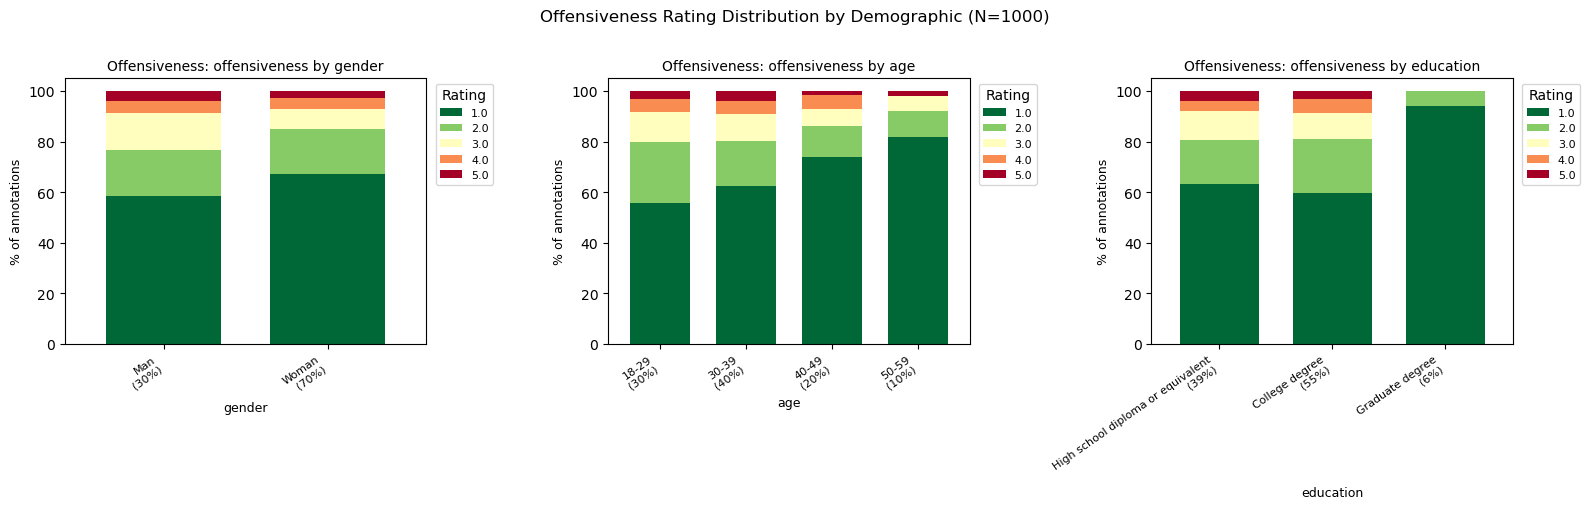

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, DEMO_COLS):
    common = get_common_groups(off, pol, col)
    plot_rating_by_demo(off, 'offensiveness', col, 'Offensiveness', ax, common_groups=common)
plt.suptitle('Offensiveness Rating Distribution by Demographic (N=1000)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Mean Rating by Demographic Group — Offensiveness

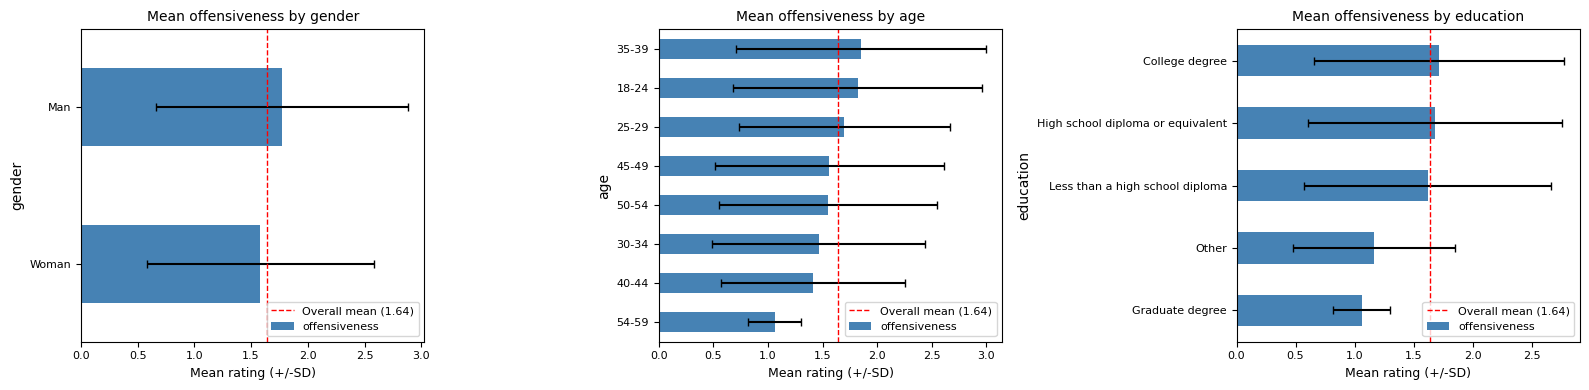

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
overall_off = off['offensiveness'].mean()
for ax, col in zip(axes, DEMO_COLS):
    means = off.groupby(col)['offensiveness'].mean().sort_values()
    stds  = off.groupby(col)['offensiveness'].std()
    means.plot(kind='barh', xerr=stds[means.index], ax=ax, color='steelblue', capsize=3)
    ax.set_title(f'Mean offensiveness by {col}', fontsize=10)
    ax.set_xlabel('Mean rating (+/-SD)', fontsize=9)
    ax.axvline(overall_off, color='red', linestyle='--', linewidth=1, label=f'Overall mean ({overall_off:.2f})')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

---
## 2. Politeness

In [34]:
descriptive_stats(pol['politeness'], 'Politeness')


Politeness — Descriptive Statistics (N=1000)
  Mean   : 3.206
  Median : 3.0
  Std    : 1.299
  Min    : 1  |  Max: 5

  Rating distribution:
    1:  144 ( 14.4%) ███████
    2:  133 ( 13.3%) ██████
    3:  292 ( 29.2%) ██████████████
    4:  235 ( 23.5%) ███████████
    5:  196 ( 19.6%) █████████


### 2.1 Chi-Squared Tests — Politeness

In [35]:
pol_results = run_all_tests(pol, 'politeness', 'Politeness')


############################################################
  Chi-Squared Tests: Politeness ~ Demographic Group
  H0: rating distribution is independent of demographic group
  alpha = 0.05
############################################################

  [gender]
    N = 1000
    chi2(8) = 68.888,  p = 0.0000  ** SIGNIFICANT (alpha=0.05) **
    Direction (mean rating per group, highest → lowest):
      Man: 3.2841530054644807  [above avg]
      Woman: 3.112219451371571  [below avg]
      Non-binary: 3.1  [below avg]
    → 'Man' rates highest (3.2841530054644807); 'Non-binary' rates lowest (3.1)

  [age]
    N = 1000
    chi2(24) = 82.405,  p = 0.0000  ** SIGNIFICANT (alpha=0.05) **
    Direction (mean rating per group, highest → lowest):
      50-54: 3.58  [above avg]
      40-44: 3.49  [above avg]
      25-29: 3.42  [above avg]
      45-49: 3.4066666666666667  [above avg]
      30-34: 3.140562248995984  [below avg]
      18-24: 2.8955223880597014  [below avg]
      35-39: 2.83  [below

### 2.2 Contingency Tables — Politeness

In [36]:
for res in pol_results:
    print(f"\n--- {res['demographic']} x politeness ---")
    ct = res['contingency_table']
    display(ct.assign(Total=ct.sum(axis=1)))
    print("Row %:")
    display(ct.div(ct.sum(axis=1), axis=0).mul(100).round(1))


--- gender x politeness ---


politeness,1.0,2.0,3.0,4.0,5.0,Total
gender,,,,,,
Man,51,66,199,142,91,549
Non-binary,5,8,19,13,5,50
Woman,88,59,74,80,100,401


Row %:


politeness,1.0,2.0,3.0,4.0,5.0
gender,,,,,
Man,9.3,12.0,36.2,25.9,16.6
Non-binary,10.0,16.0,38.0,26.0,10.0
Woman,21.9,14.7,18.5,20.0,24.9



--- age x politeness ---


...

politeness,1.0,2.0,3.0,4.0,5.0
age,,,,,
18-24,25.4,12.4,24.4,22.9,14.9
25-29,8.0,20.0,22.0,22.0,28.0
30-34,16.5,14.9,26.1,23.3,19.3
35-39,20.0,20.0,28.0,21.0,11.0
40-44,5.5,12.0,35.5,22.0,25.0
45-49,11.3,10.7,28.0,26.0,24.0
50-54,0.0,2.0,52.0,32.0,14.0



--- education x politeness ---


politeness,1.0,2.0,3.0,4.0,5.0,Total
education,,,,,,
College degree,82,94,129,107,89,501
Graduate degree,13,8,31,48,49,149
High school diploma or equivalent,48,26,103,68,55,300
Prefer not to disclose,1,5,29,12,3,50


Row %:


politeness,1.0,2.0,3.0,4.0,5.0
education,,,,,
College degree,16.4,18.8,25.7,21.4,17.8
Graduate degree,8.7,5.4,20.8,32.2,32.9
High school diploma or equivalent,16.0,8.7,34.3,22.7,18.3
Prefer not to disclose,2.0,10.0,58.0,24.0,6.0


### 2.3 Rating Distribution by Demographic — Politeness

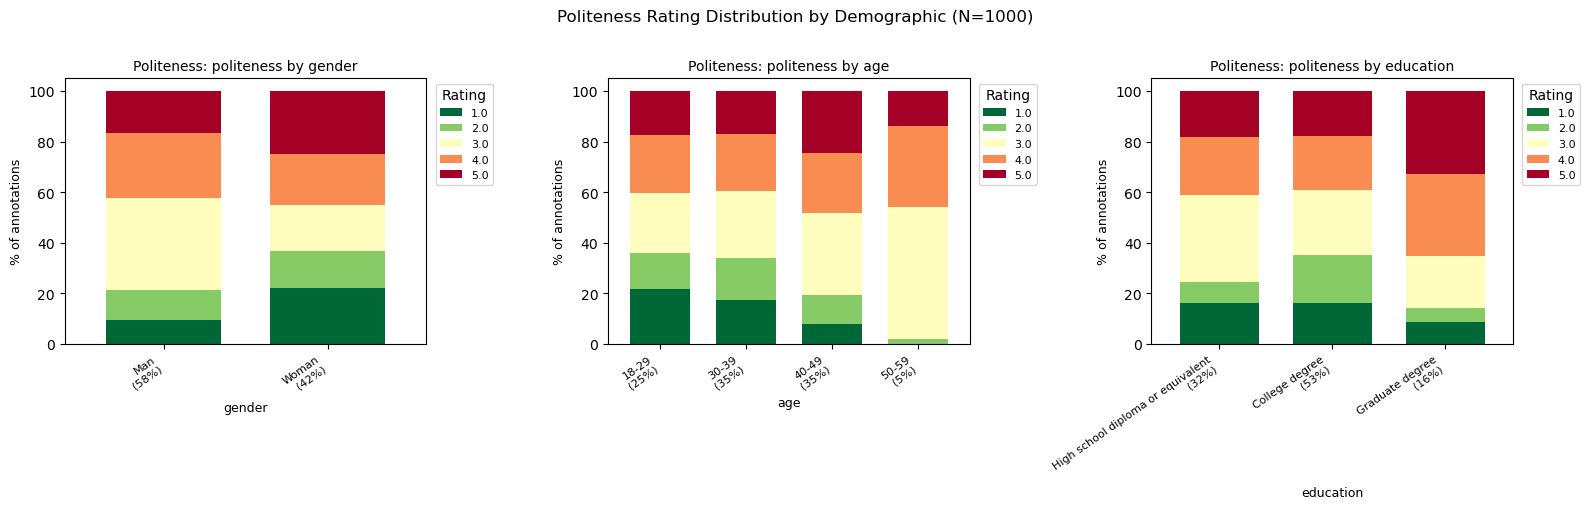

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, DEMO_COLS):
    common = get_common_groups(off, pol, col)
    plot_rating_by_demo(pol, 'politeness', col, 'Politeness', ax, common_groups=common)
plt.suptitle('Politeness Rating Distribution by Demographic (N=1000)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Mean Rating by Demographic Group — Politeness

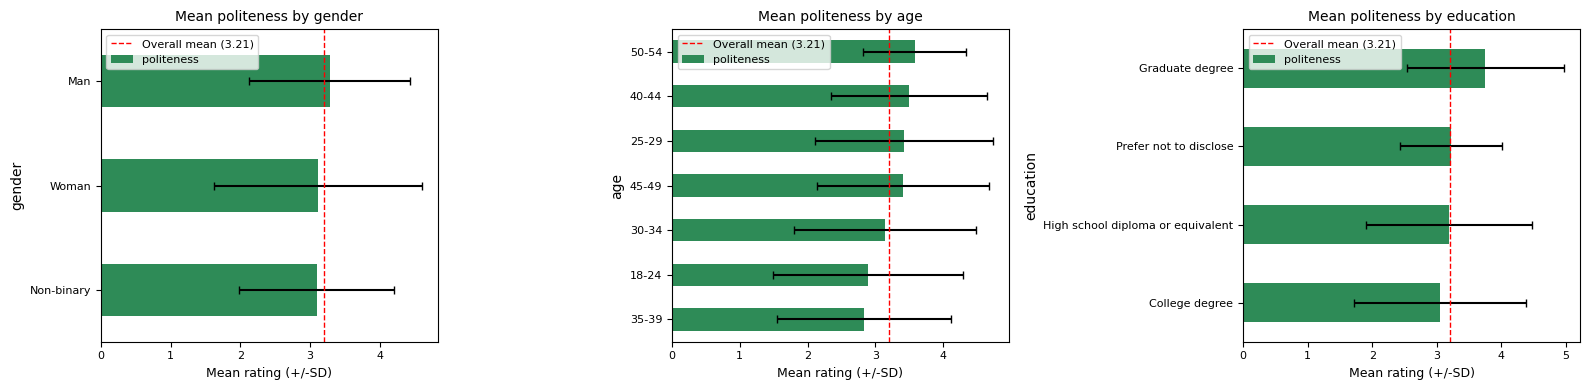

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
overall_pol = pol['politeness'].mean()
for ax, col in zip(axes, DEMO_COLS):
    means = pol.groupby(col)['politeness'].mean().sort_values()
    stds  = pol.groupby(col)['politeness'].std()
    means.plot(kind='barh', xerr=stds[means.index], ax=ax, color='seagreen', capsize=3)
    ax.set_title(f'Mean politeness by {col}', fontsize=10)
    ax.set_xlabel('Mean rating (+/-SD)', fontsize=9)
    ax.axvline(overall_pol, color='red', linestyle='--', linewidth=1, label=f'Overall mean ({overall_pol:.2f})')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

---
## 3. Summary Table

In [39]:
summary = pd.concat([
    summary_table(off_results, 'Offensiveness'),
    summary_table(pol_results,  'Politeness'),
], ignore_index=True)

def highlight_sig(row):
    if row['Significant (alpha=0.05)'] == 'Yes':
        return ['background-color: #d4edda'] * len(row)
    return [''] * len(row)

display(summary.style.apply(highlight_sig, axis=1).format({'p-value': '{:.4f}', 'chi2': '{:.3f}'}))

,Task,Demographic,N,chi2,df,p-value,Significant (alpha=0.05),% cells expected<5
0,Offensiveness,gender,1000,13.305,4,0.0099,Yes,0.000000
1,Offensiveness,age,1000,90.261,28,0.0000,Yes,32.500000
2,Offensiveness,education,1000,49.837,16,0.0000,Yes,36.000000
3,Politeness,gender,1000,68.888,8,0.0000,Yes,0.000000
4,Politeness,age,1000,82.405,24,0.0000,Yes,0.000000
5,Politeness,education,1000,81.772,12,0.0000,Yes,0.000000


---
## 4. Interpretation

The **chi-squared test of independence** tests whether the distribution of ratings (1–5) differs significantly across demographic subgroups.

- **H0:** Rating distribution is independent of the demographic group (all groups rate similarly).
- **H1:** There is a significant association between demographic group and rating distribution.
- **alpha = 0.05**

A **significant result (p < 0.05)** indicates that annotators from different demographic groups gave systematically different ratings — suggesting **perspective divergence** tied to that demographic characteristic.

> **Note on chi-squared assumptions:** Chi-squared requires expected cell counts >= 5 in at least 80% of cells. Where this assumption is violated (flagged above), interpret results with caution — Fisher's exact test or merging small categories would be appropriate alternatives.

In [6]:
# num rows in original 

import pandas as pd

df_offensiveness = pd.read_csv("../../dataset/offensiveness/raw_data.csv")
df_politeness = pd.read_csv("../../dataset/politeness_rating/raw_data.csv")

total_rows_offensiveness = len(df_offensiveness)
print("Total Rows in offensiveness", total_rows_offensiveness)

total_rows_politeness = len(df_politeness)
print("Total Rows in politeness", total_rows_politeness)

unique_texts_offensiveness = df_offensiveness["text"].nunique()
print("Unique texts in offensiveness", unique_texts_offensiveness)
df_offensiveness["text"].value_counts()

unique_texts_politeness = df_politeness["text"].nunique()
print("Unique texts in politeness", unique_texts_politeness)
df_politeness["text"].value_counts()

# unique texts in our sample 
df_llm_p = pd.read_csv("../../dataset/politeness_rating/raw_data_llm.csv")
print(len(df_llm_p))
unique_texts_first_1000 = df_llm_p.head(1000)["text"].nunique()

print("How many unique texts in first 1000 rows of politeness:", unique_texts_first_1000)

df_llm_o = pd.read_csv("../../dataset/offensiveness/raw_data_llm.csv")
print(len(df_llm_o))
unique_texts_first_1000 = df_llm_o.head(1000)["text"].nunique()

print("How many unique texts in first 1000 rows of offensiveness:", unique_texts_first_1000)



# num original texts 

Total Rows in offensiveness 13036
Total Rows in politeness 25042
Unique texts in offensiveness 1500
Unique texts in politeness 3718
25042
How many unique texts in first 1000 rows of politeness: 1000
13036
How many unique texts in first 1000 rows of offensiveness: 1000


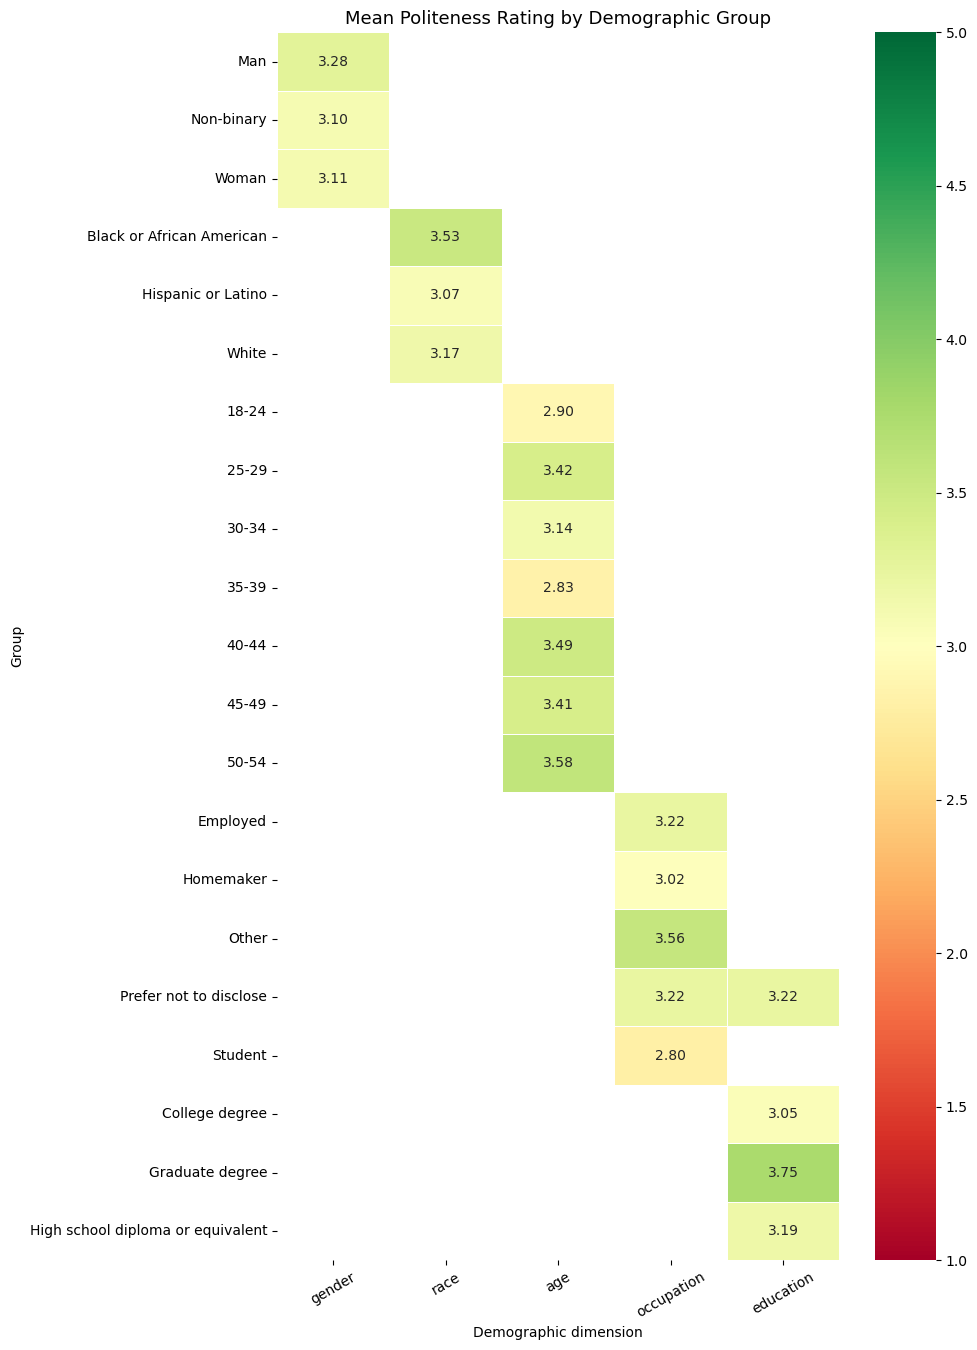

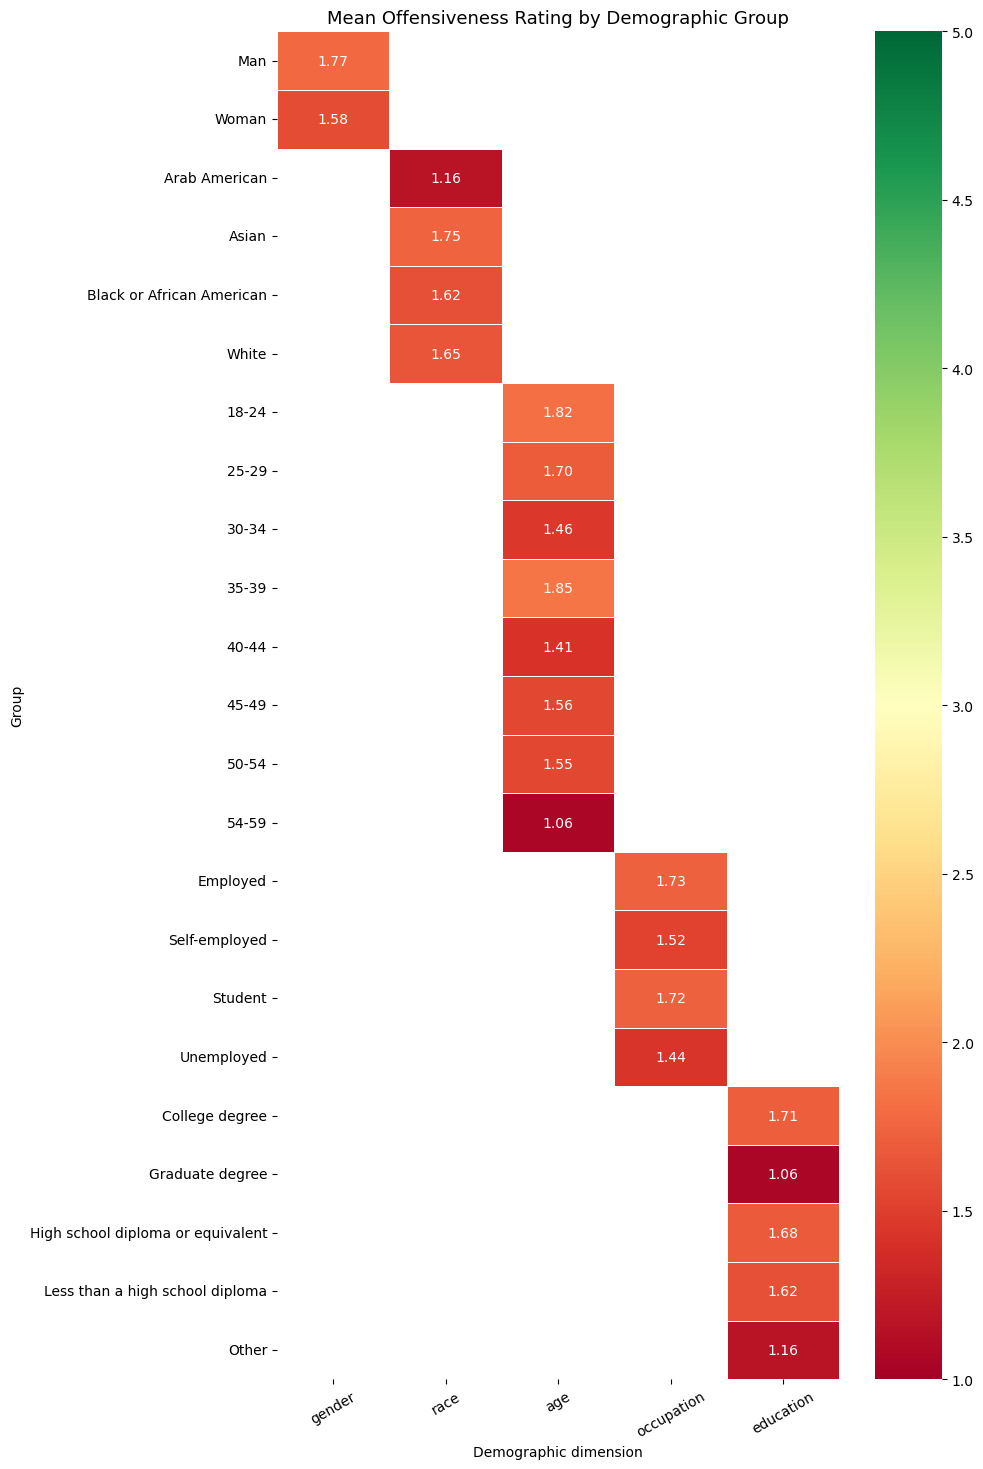

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Load your data ---
df = pd.read_csv("your_file.csv")  # <-- change to your filename

# --- Config: which demographic columns to include ---
demographic_cols = ["gender", "race", "age", "occupation", "education"]

# --- Build heatmap data ---
fig, axes = plt.subplots(1, len(demographic_cols), figsize=(18, 6))
fig.suptitle("Average Politeness Rating by Demographic", fontsize=16, fontweight="bold", y=1.02)

for ax, col in zip(axes, demographic_cols):
    pivot = (
        df.groupby(col)["politeness"]
        .mean()
        .reset_index()
        .rename(columns={"politeness": "avg_politeness"})
        .set_index(col)
    )
    
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        vmin=df["politeness"].min(),
        vmax=df["politeness"].max(),
    )
    ax.set_title(col.capitalize(), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("politeness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to politeness_heatmap.png")